## Factores asociados a mortalidad intrahospitalaria

**Proyecto:** Avance 1 - Análisis de Datos e Inferencia Estadística  
**Integrantes:** Agustín Reyes & Matías Mouat  

**Preguntas de Investigación:**
1. ¿En qué medida la presencia de una causa de muerte secundaria actúa como un factor acelerador de la mortalidad en adultos en edad laboral (25-64 años)?

2. ¿Existe una correlación significativa entre los meses de invierno (junio-agosto) y un aumento en las defunciones por enfermedades del sistema respiratorio en comparación con otras causas?

3. ¿Existen diferencias estadísticamente significativas en la esperanza de vida observada (edad de defunción) entre géneros al segmentar por regiones de Chile durante el periodo 2023-2025?

4. ¿Difiere el perfil epidemiológico de mortalidad entre regiones?

5. ¿Qué causas generan mayor pérdida de vida productiva?


## 1. Introducción y Contexto

El presente estudio busca caracterizar los patrones de mortalidad en Chile tras la crisis sanitaria global.  
Según el reporte oficial, Chile experimentó un aumento del 4,0% en las defunciones durante 2024.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
import statsmodels.api as sm

# Configuración de estética visual limpia y geométrica para los gráficos
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.rcParams['figure.figsize'] = (10, 6)    

# Ajuste de parámetros de visualización en Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Paso 1: Ingesta y Configuración del Entorno
Para empezar, se procedió a la carga del dataset oficial del DEIS en formato CSV. Debido a la naturaleza del archivo, fue necesario configurar la codificación en latin-1 y establecer el separador de punto y coma (;). Además, se ajustaron los parámetros de visualización en Pandas para permitir una inspección completa de los registros, facilitando así una primera aproximación al contenido del dataset.

In [2]:
# Carga de datos (Asegúrate de que el nombre del archivo coincida con tu ruta local)
ruta_archivo = "DEFUNCIONES_FUENTE_DEIS_2023_2026_04032026.csv"
df = pd.read_csv(ruta_archivo, encoding='latin-1', sep=';')

print(f"Dimensiones iniciales del dataset: {df.shape}")

Dimensiones iniciales del dataset: (394976, 27)


In [3]:
df.columns

Index(['AÑO', 'FECHA_DEF', 'SEXO_NOMBRE', 'EDAD_TIPO', 'EDAD_CANT', 'COD_COMUNA', 'COMUNA', 'NOMBRE_REGION', 'DIAG1', 'CAPITULO_DIAG1', 'GLOSA_CAPITULO_DIAG1', 'CODIGO_GRUPO_DIAG1', 'GLOSA_GRUPO_DIAG1', 'CODIGO_CATEGORIA_DIAG1', 'GLOSA_CATEGORIA_DIAG1', 'CODIGO_SUBCATEGORIA_DIAG1', 'GLOSA_SUBCATEGORIA_DIAG1', 'DIAG2', 'CAPITULO_DIAG2', 'GLOSA_CAPITULO_DIAG2', 'CODIGO_GRUPO_DIAG2', 'GLOSA_GRUPO_DIAG2', 'CODIGO_CATEGORIA_DIAG2', 'GLOSA_CATEGORIA_DIAG2', 'CODIGO_SUBCATEGORIA_DIAG2', 'GLOSA_SUBCATEGORIA_DIAG2', 'LUGAR_DEFUNCION'], dtype='str')

### Paso 2: Exploración Inicial y Clasificación de Variables
Después, se realizó una clasificación de las variables disponibles, priorizando aquellas de mayor relevancia epidemiológica para el estudio. En esta etapa, se descartaron variables que no aportaban valor directo al análisis, como el lugar de defunción o la estacionalidad, con el objetivo de mantener un enfoque claro. 

De esta forma, se trabajó principalmente con variables cualitativas como género, región y diagnóstico principal y secundario, junto con la variable cuantitativa de edad. Asimismo, se utilizaron funciones exploratorias como .info() y .head() para comprender la estructura de los datos e identificar posibles valores nulos.

In [4]:
# Seleccionar solo las variables de interés para aislar el ruido
columnas_relevantes = [
    'FECHA_DEF', 'EDAD_CANT', 'SEXO_NOMBRE', 'NOMBRE_REGION', 
    'GLOSA_CAPITULO_DIAG1', 'GLOSA_CAPITULO_DIAG2'
]
df = df[columnas_relevantes]

# Exploración de estructura y nulos
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 394976 entries, 0 to 394975
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   FECHA_DEF             394976 non-null  str  
 1   EDAD_CANT             394976 non-null  int64
 2   SEXO_NOMBRE           394976 non-null  str  
 3   NOMBRE_REGION         394920 non-null  str  
 4   GLOSA_CAPITULO_DIAG1  394971 non-null  str  
 5   GLOSA_CAPITULO_DIAG2  25462 non-null   str  
dtypes: int64(1), str(5)
memory usage: 18.1 MB


,FECHA_DEF,EDAD_CANT,SEXO_NOMBRE,NOMBRE_REGION,GLOSA_CAPITULO_DIAG1,GLOSA_CAPITULO_DIAG2
0,2026-02-15,81,Hombre,Metropolitana de Santiago,Enfermedades del sistema circulatorio,NaN
1,2026-01-23,97,Mujer,Metropolitana de Santiago,Enfermedades del sistema circulatorio,NaN
2,2026-01-05,93,Hombre,Metropolitana de Santiago,Enfermedades del sistema circulatorio,NaN
3,2026-02-14,88,Hombre,Metropolitana de Santiago,"Enfermedades endocrinas, nutricionales y metab...",NaN
4,2026-01-05,89,Mujer,Metropolitana de Santiago,Enfermedades del sistema respiratorio,NaN


### Paso 3: Limpieza y Transformación de Datos (Data Cleaning)
Seguido de esto, se llevó a cabo el proceso de limpieza y transformación de los datos. En primer lugar, la variable de fecha de defunción fue convertida a formato datetime para permitir su manipulación adecuada. Luego, se aplicaron filtros de calidad, eliminando registros categóricos que no aportaban valor analítico, como la categoría “Ignorada” en la variable de región, y restringiendo la variable de género a las categorías “Hombre” y “Mujer”. 

Adicionalmente, se realizó ingeniería de características, creando la variable booleana TIENE_SECUNDARIA para identificar la presencia de comorbilidades, y se delimitó el análisis a la población en edad laboral activa, comprendida entre los 25 y 64 años.

In [5]:
# Normalización Temporal y de Edad
df['FECHA_DEF'] = pd.to_datetime(df['FECHA_DEF'], errors='coerce')
df['EDAD_CANT'] = pd.to_numeric(df['EDAD_CANT'], errors='coerce')

# Filtros
df = df.dropna(subset=['FECHA_DEF', 'EDAD_CANT']) 
df = df[df['NOMBRE_REGION'] != 'Ignorada']
df = df[df['SEXO_NOMBRE'].isin(['Hombre', 'Mujer'])]

# Variable Booleana
df['TIENE_SECUNDARIA'] = df['GLOSA_CAPITULO_DIAG2'].notna()
df['AÑO'] = df['FECHA_DEF'].dt.year

# Delimitación a edad laboral activa (25 a 64 años)
# Usamos .copy() para crear un dataframe independiente
#df_lab = df[(df['EDAD_CANT'] >= 25) & (df['EDAD_CANT'] <= 64)].copy()

#print(f"Registros en edad laboral tras la limpieza: {df_lab.shape[0]}")

### Paso 3.5: Impacto de Comorbilidades en la Mortalidad Laboral

In [ ]:
# Calcular las medias exactas para mostrarlas en el gráfico
media_sin = df_lab[df_lab['TIENE_SECUNDARIA'] == False]['EDAD_CANT'].mean()
media_con = df_lab[df_lab['TIENE_SECUNDARIA'] == True]['EDAD_CANT'].mean()

# Gráfico Boxplot
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=df_lab,
    x='TIENE_SECUNDARIA',
    y='EDAD_CANT',
    palette=['#3498db', '#e74c3c'], 
    
)

# Estética
plt.xticks([0,1], ['Sin causa secundaria', 'Con causa secundaria'], fontweight='bold', fontsize=11)
plt.ylabel("Edad al fallecer", fontweight='bold', fontsize=11)
plt.xlabel("Presencia de Diagnóstico Secundario", fontweight='bold', fontsize=11)
plt.title("Impacto de Causa Secundaria en Edad de Mortalidad (25–64 años)", fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Paso 4: Análisis Descriptivo y Perfil Epidemiológico
A continuación, se desarrolló el análisis descriptivo, segmentando el dataset en subconjuntos anuales para el período 2023–2026. Para cada uno de estos segmentos se calcularon medidas de tendencia central, como la media y la mediana, así como medidas de dispersión para la edad. 

Paralelamente, mediante operaciones de agrupamiento, se identificaron las principales causas de muerte por región, lo que permitió construir un perfil epidemiológico territorial.

In [ ]:

# Medidas de tendencia central y dispersión por año
desc_anual = df_lab.groupby('AÑO')['EDAD_CANT'].agg(['mean', 'median', 'std', 'count']).round(2)
desc_anual.columns = ['Media Edad', 'Mediana Edad', 'Desviación Estándar', 'Total Casos']
display(desc_anual)

# Perfil Epidemiológico: Causa principal por región
perfil = df.groupby('NOMBRE_REGION')['GLOSA_CAPITULO_DIAG1'] \
           .value_counts(normalize=True).unstack()
perfil = perfil.drop(index='Ignorada', errors='ignore')

# Top 3 causas nacionales
top_3_causas = perfil.mean().sort_values(ascending=False).index[:3]
perfil_top3 = perfil[top_3_causas]

# Ordenar
causa_principal = top_3_causas[0]
perfil_top3 = perfil_top3.sort_values(by=causa_principal, ascending=True)

# Acortar nombres
perfil_top3.index = perfil_top3.index.str.replace("Región de ", "")
perfil_top3.index = perfil_top3.index.str.slice(0, 25) + '...'
colores = ['#4c72b0', '#dd8452', '#55a868']

fig, ax = plt.subplots(figsize=(10, 8))
perfil_top3.plot(
    kind='barh',
    stacked=True,
    color=colores,
    edgecolor='white',
    linewidth=1,
    ax=ax
)
ax.set_title("Distribución de las 3 Principales Causas de Muerte por Región",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Proporción de Defunciones")
ax.set_ylabel("Región")
plt.legend(
    title="Top 3 Causas",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Paso 4.5: Análisis de Estacionalidad y Enfermedades Respiratorias

In [ ]:
# Pregunta 2
# Extraer el mes de defunción
df_lab['MES'] = df_lab['FECHA_DEF'].dt.month

# Definir Invierno (Meses 6, 7 y 8)
df_lab['ES_INVIERNO'] = df_lab['MES'].isin([6, 7, 8])

# Definir si la causa fue respiratoria (Devuelve un booleano True/False)
df_lab['ES_RESPIRATORIO'] = df_lab['GLOSA_CAPITULO_DIAG1'].str.contains('respiratorio', case=False, na=False)

# Calcular el porcentaje de defunciones respiratorias por estación
# Alsobre una variable booleana (True=1, False=0) para obtener la proporción directamente.
temp = df_lab.groupby('ES_INVIERNO')['ES_RESPIRATORIO'].mean() * 100

# Calcular la diferencia 
diff = temp[True] - temp[False]
plt.figure(figsize=(9, 6))


ax = temp.plot(kind='bar', color=['#4c72b0', '#dd8452'])
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.xticks([0, 1], ['Resto del Año', 'Invierno'], rotation=0, fontweight='bold', fontsize=11)
plt.ylabel("Proporción de Mortalidad Respiratoria (%)", fontweight='bold', fontsize=11)
plt.xlabel("") 
plt.ylim(0, temp.max() + 5) 

# Añadir Etiquetas exactas sobre cada barra
for i, v in enumerate(temp):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', color='#2c3e50', fontweight='bold')

plt.title(f"Impacto del Invierno en Mortalidad Respiratoria (+{diff:.1f} pp)", fontweight='bold', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Paso 5: Análisis de la Brecha de Género a Nivel Regional
Después, se abordó el análisis de la brecha de género a nivel regional. Para ello, se agruparon los datos por región y sexo, calculando la edad promedio de fallecimiento en cada grupo. A partir de estos resultados, se estimó la diferencia absoluta entre mujeres y hombres, lo que permitió visualizar la magnitud de esta brecha y su variabilidad a lo largo del país.

In [ ]:
# Pregunta 3
# Filtro base para limpiar 'Ignorada'
df_limpio = df[df['NOMBRE_REGION'] != 'Ignorada']

# Calcular las edades promedio
longevidad = df_limpio.groupby(['NOMBRE_REGION', 'SEXO_NOMBRE'])['EDAD_CANT'].mean().unstack()
longevidad = longevidad[['Hombre', 'Mujer']]
longevidad['diff'] = longevidad['Mujer'] - longevidad['Hombre']

# Encontrar la causa principal por región
causa_principal = df_limpio.groupby('NOMBRE_REGION')['GLOSA_CAPITULO_DIAG1'].agg(lambda x: x.value_counts().index[0])
longevidad['Causa_Top'] = causa_principal

# Ordenar por la edad promedio de las mujeres para darle un flujo visual
longevidad = longevidad.sort_values('Mujer', ascending=True)


sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False})
fig, ax = plt.subplots(figsize=(12, 10))

y = np.arange(len(longevidad.index))
alto_barra = 0.35  


ax.barh(y - alto_barra/2, longevidad['Hombre'], alto_barra, label='Hombres', color='#2c3e50', edgecolor='white', linewidth=1.5)
ax.barh(y + alto_barra/2, longevidad['Mujer'], alto_barra, label='Mujeres', color='#e74c3c', edgecolor='white', linewidth=1.5)

# 5. Añadir anotaciones (Causa Top y Brecha de años)
for i, (idx, row) in enumerate(longevidad.iterrows()):
    causa = row['Causa_Top']
    if 'circulatorio' in causa.lower():
        causa_texto = 'Cardiovascular'
    elif 'tumores' in causa.lower() or 'neoplasias' in causa.lower():
        causa_texto = 'Tumores'
    elif 'respiratorio' in causa.lower():
        causa_texto = 'Respiratorio'
    else:
        causa_texto = causa[:15] + '...'


    max_val = max(row['Hombre'], row['Mujer'])
    

    ax.text(max_val + 1, i, f"Top 1: {causa_texto} (+{row['diff']:.1f} años)", 
            va='center', ha='left', fontsize=10, color='#34495e', 
            fontstyle='italic', fontweight='bold')


ax.set_yticks(y)
ax.set_yticklabels(longevidad.index, fontweight='bold', fontsize=11)
ax.set_xlabel("Edad Promedio de Defunción", fontweight='bold')
ax.set_title("Edad Promedio por Género y Causa Principal Regional", fontweight='bold', fontsize=15, pad=20)

ax.set_xlim(60, 95) 

ax.legend(loc='lower right', frameon=True, fontsize=11, facecolor='#f8f9fa', edgecolor='none')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Paso 6: Cálculo de Años de Vida Potencialmente Perdidos (AVPP)
Finalmente, se calculó el indicador de Años de Vida Potencialmente Perdidos (AVPP), restando la edad de defunción al umbral teórico de vida laboral (65 años). Los resultados fueron agrupados por capítulo de diagnóstico, lo que permitió identificar aquellas causas que generan mayor impacto en términos de pérdida de vida productiva. 

Es importante destacar que se decidió mantener los valores atípicos correspondientes a edades muy bajas, ya que representan casos reales de mortalidad prematura y no errores en los datos.

In [ ]:
#Pregunta 5
# Crear AVPP
df['AVPP'] = df['EDAD_CANT'].apply(lambda x: 65 - x if x < 65 else 0)

impacto = df.groupby('GLOSA_CAPITULO_DIAG1')['AVPP'] \
            .sum() \
            .sort_values(ascending=False) \
            .head(10)
impacto = impacto.sort_values(ascending=True)

# acortar nombres
impacto.index = impacto.index.str.slice(0, 50) + '...'

plt.figure(figsize=(10, 6))

colors = ['#a6bddb'] * len(impacto)
colors[-1] = '#d7301f'

plt.barh(impacto.index, impacto.values, color=colors)

for i, v in enumerate(impacto):
    plt.text(v + 5000, i, f"{int(v):,}", va='center')

plt.xlabel("Años de Vida Potencialmente Perdidos (AVPP)")
plt.title("Principales Causas de Muerte según AVPP")
plt.tight_layout()
plt.show()

### Paso 7: Modelado Predictivo (Regresión Lineal)
En la siguiente etapa, se implementó un modelo de regresión lineal con el objetivo de analizar la evolución del volumen de mortalidad. Este modelo fue entrenado utilizando los totales históricos disponibles agrupados mensualmente, permitiendo proyectar la tendencia de defunciones hacia periodos futuros y observar posibles comportamientos crecientes o estables.

In [ ]:

sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
anos_reales = np.array([2023, 2024, 2025]).reshape(-1, 1)
totales_reales = np.array([122218, 126934, 126454])


modelo = LinearRegression()
modelo.fit(anos_reales, totales_reales)
anos_pred = np.array([2026, 2027]).reshape(-1, 1)
totales_pred = modelo.predict(anos_pred)

fig, ax = plt.subplots(figsize=(10, 6))
anos_linea = np.array([2023, 2024, 2025, 2026, 2027]).reshape(-1, 1)
ax.plot(anos_linea, modelo.predict(anos_linea), color='#95a5a6', linestyle='--', linewidth=2, zorder=1)
ax.scatter(anos_reales, totales_reales, color='#2c3e50', s=120, marker='D', label='Datos Históricos', zorder=2)
ax.scatter(anos_pred, totales_pred, color='#e74c3c', s=150, marker='X', label='Proyección', zorder=2)

def formato_miles(x):
    return f"{int(x):,}".replace(',', '.')

for i in range(len(anos_reales)):
    ax.annotate(formato_miles(totales_reales[i]), 
                (anos_reales[i][0], totales_reales[i]), 
                textcoords="offset points", xytext=(0,12), ha='center', 
                color='#2c3e50', weight='bold', fontsize=10)

for i in range(len(anos_pred)):
    ax.annotate(formato_miles(totales_pred[i]), 
                (anos_pred[i][0], totales_pred[i]), 
                textcoords="offset points", xytext=(0,12), ha='center', 
                color='#e74c3c', weight='bold', fontsize=11)

ax.set_title('Proyección de Defunciones Totales en Chile (2023-2027)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Año', fontsize=12, fontweight='bold')
ax.set_ylabel('Total de Defunciones', fontsize=12, fontweight='bold')
ax.set_xticks([2023, 2024, 2025, 2026, 2027])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: formato_miles(x)))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

# AVANCE 2

Pregunta seleccionada: ¿Cómo influyen conjuntamente el género, la región de residencia y la presencia de una comorbilidad (causa secundaria) en la edad de defunción poblacional?

## Pregunta de hipotesis
Hipótesis Nula ($H_0$)
El modelo no tiene capacidad predictiva. Ninguna de las variables independientes influye en la edad de defunción

$H_0: \beta_1 = \beta_2 = \beta_i = 0$

Hipótesis Alternativa ($H_1$): El modelo sí tiene capacidad predictiva. Al menos una de las variables independientes influye significativamente en la edad de defunción.

$H_1: \text{Al menos un } \beta \neq 0$



### Modelamiento Predictivo: Regresión Lineal Múltiple por Cohortes

Para que el modelo cumpla con los estándare estádisticos se implementó una Regresión por Cohortes Demográficas: 

- Cambio de Unidad de Análisis: Pasamos del individuo al "Grupo Demográfico" (segmentado por sexo, región, comorbilidad y diagnóstico). Al predecir la EDAD_PROMEDIO del grupo, eliminamos valores atípicos individuales, permitiendo que el modelo capture las tendencias estructurales de mortalidad en Chile.

- Mínimos Cuadrados Ponderados (WLS): Se utiliza el modelo Weighted Least Squares utilizando el PESO_MUESTRAL (conteo de personas por grupo). Esto otorga mayor importancia estadística a las cohortes más representativas (con más casos), asegurando que los resultados no se vean sesgados por grupos minoritarios.

- Filtrado de Representatividad: Se descartan grupos con menos de 5 observaciones para evitar promedios engañosos que no representen una tendencia poblacional real.

### Variables dependientes e independientes

#### Variables Dependientes:

- EDAD_CANT (Edad del fallecido)

#### Variables Independientes:

- TIENE_SECUNDARIA

- SEXO_NOMBRE

- NOMBRE_REGION

In [ ]:


# 1. Seleccionar columnas
columnas = ['EDAD_CANT', 'SEXO_NOMBRE', 'NOMBRE_REGION', 'TIENE_SECUNDARIA', 'GLOSA_CAPITULO_DIAG1']
df_modelo = df[columnas].dropna().copy()

# 2. EL TRUCO ESTADÍSTICO: Agrupar por todas las características y calcular la EDAD PROMEDIO
# Esto cambia la unidad de análisis de "Individuo" a "Cohorte/Grupo Demográfico"
df_agrupado = df_modelo.groupby(
    ['SEXO_NOMBRE', 'NOMBRE_REGION', 'TIENE_SECUNDARIA', 'GLOSA_CAPITULO_DIAG1']
).agg(
    EDAD_PROMEDIO=('EDAD_CANT', 'mean'), # Nueva variable dependiente (Y)
    PESO_MUESTRAL=('EDAD_CANT', 'count') # Cuánta gente hay en este grupo (opcional, para dar contexto)
).reset_index()

# Filtramos grupos que tengan muy poca gente (ej. menos de 5 personas) para evitar promedios engañosos
df_agrupado = df_agrupado[df_agrupado['PESO_MUESTRAL'] >= 5]

# 3. Generar las variables Dummy sobre el dataset AGRUPADO
df_dummies = pd.get_dummies(
    df_agrupado, 
    columns=['SEXO_NOMBRE', 'NOMBRE_REGION', 'TIENE_SECUNDARIA', 'GLOSA_CAPITULO_DIAG1'], 
    drop_first=True, 
    dtype=int
)

df_dummies.columns = df_dummies.columns.str.replace(' ', '_').str.replace('-', '_').str.replace(',', '').str.replace('.', '').str.replace('(', '').str.replace(')', '')

# 4. Definir Variable Dependiente (Y) e Independientes (X)
y = df_dummies['EDAD_PROMEDIO']  # ATENCIÓN: Ahora predecimos el promedio del grupo
X = df_dummies.drop(['EDAD_PROMEDIO', 'PESO_MUESTRAL'], axis=1)

X = sm.add_constant(X)

# 5. Ajustar el Modelo (Usamos WLS - Mínimos Cuadrados Ponderados, para darle más peso a los grupos grandes)
# Si prefieres el modelo normal, puedes usar sm.OLS(y, X).fit()
modelo_agrupado = sm.WLS(y, X, weights=df_agrupado['PESO_MUESTRAL']).fit()

print("--- RESUMEN DEL MODELO SOBRE COHORTES DEMOGRÁFICAS ---")
print(modelo_agrupado.summary())

--- RESUMEN DEL MODELO SOBRE COHORTES DEMOGRÁFICAS ---
                            WLS Regression Results                            
Dep. Variable:          EDAD_PROMEDIO   R-squared:                       0.950
Model:                            WLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     284.6
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        20:14:05   Log-Likelihood:                -1573.3
No. Observations:                 547   AIC:                             3217.
Df Residuals:                     512   BIC:                             3367.
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                                                                                                                     coef  

El modelo alcanza un $R^2$ de 0.950, lo que indica que los factores demográficos y clínicos seleccionados explican el 95% de la varianza en la longevidad promedio de las cohortes. Este alto nivel de ajuste valida nuestra hipótesis global: la mortalidad en adultos en edad laboral en Chile sigue patrones predecibles basados en el perfil clínico y la ubicación geográfica.

### Visualización de Resultados: Gráfico de Coeficientes (Forest Plot)

Para comunicar eficazmente los hallazgos del modelo de regresión, se ha implementado un Gráfico de Coeficientes o Forest Plot. Esta visualización es la herramienta estándar en epidemiología y ciencias sociales para comparar simultáneamente el peso de múltiples variables sobre una variable dependiente.

A diferencia de una tabla de datos, el uso de barras de error permite visualizar los Intervalos de Confianza (95%). Si una barra de error cruza la línea punteada del cero, el factor no es estadísticamente significativo, independientemente de su magnitud.

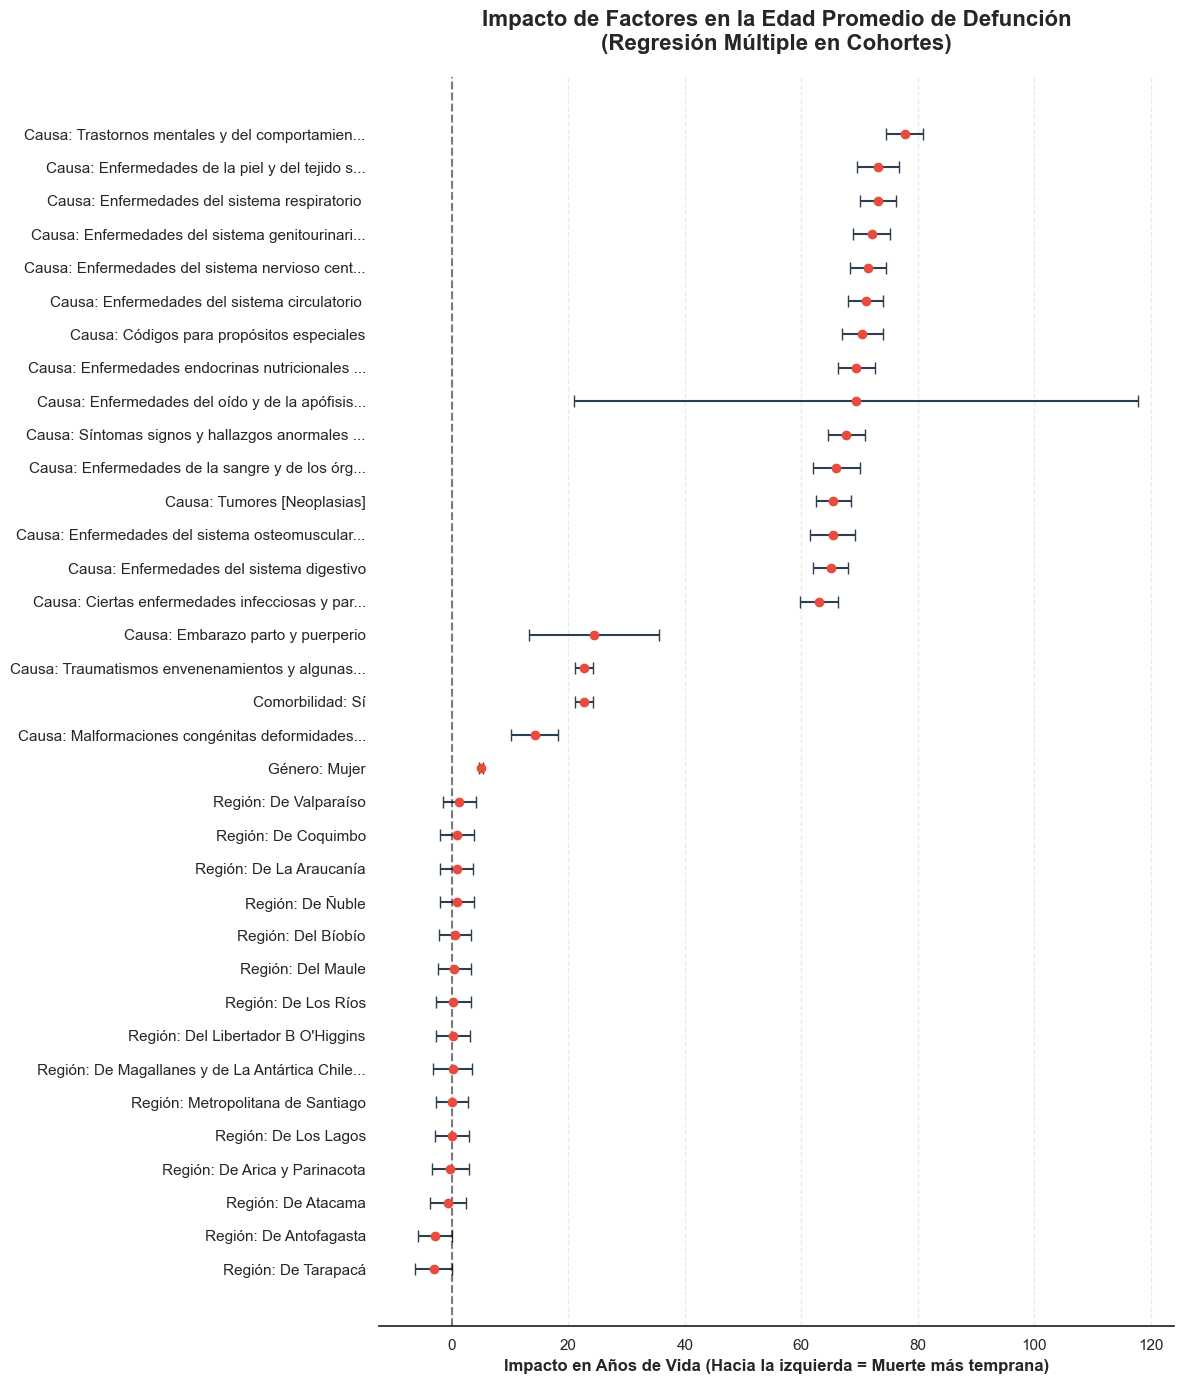

In [12]:

coeficientes = modelo_agrupado.params.drop('const')
intervalos = modelo_agrupado.conf_int(alpha=0.05).drop('const')

errores = coeficientes - intervalos[0]

df_grafico = pd.DataFrame({
    'Coeficiente': coeficientes,
    'Error': errores
}).sort_values(by='Coeficiente', ascending=True)

nombres_limpios = df_grafico.index.str.replace('NOMBRE_REGION_', 'Región: ')\
                                  .str.replace('SEXO_NOMBRE_Mujer', 'Género: Mujer')\
                                  .str.replace('TIENE_SECUNDARIA_True', 'Comorbilidad: Sí')\
                                  .str.replace('GLOSA_CAPITULO_DIAG1_', 'Causa: ')\
                                  .str.replace('_', ' ')

nombres_limpios = [nombre[:45] + '...' if len(nombre) > 45 else nombre for nombre in nombres_limpios]

fig, ax = plt.subplots(figsize=(12, 14))

ax.errorbar(df_grafico['Coeficiente'], nombres_limpios, 
            xerr=df_grafico['Error'], fmt='o', 
            color='#e74c3c', ecolor='#2c3e50', 
            capsize=4, elinewidth=1.5, markersize=6)

ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)

ax.set_title("Impacto de Factores en la Edad Promedio de Defunción\n(Regresión Múltiple en Cohortes)", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Impacto en Años de Vida (Hacia la izquierda = Muerte más temprana)", fontweight='bold', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Se observa que las causas relacionadas con malformaciones congénitas y afecciones perinatales presentan el mayor impacto negativo (desplazadas hacia la izquierda), mientras que el género femenino y ciertos diagnósticos crónicos se posicionan a la derecha del cero, confirmando las tendencias de esperanza de vida observadas en el análisis descriptivo.

### Aplicaciones del Modelo y Validación de Errores

Una vez ajustado el modelo con un alto coeficiente de determinación, es fundamental validar su utilidad práctica y su comportamiento ante datos atípicos. Esta sección se divide en dos herramientas críticas: la simulación de escenarios y el diagnóstico de errores (residuales).

El modelo de regresión no solo sirve para describir el pasado, sino como una herramienta de estimación de riesgos. Mediante una función de predicción, podemos crear "perfiles de cohorte" y observar cómo la combinación de factores geográficos y clínicos altera la esperanza de vida esperada.

Este análisis permite tangibilizar los coeficientes estadísticos en años de vida reales, facilitando la comunicación de hallazgos a audiencias no técnicas.

#### Diagnóstico de Residuales y Outliers
La validez de una regresión lineal depende de la distribución de sus errores o residuales (la diferencia entre el valor real observado y la predicción del modelo).

- Identificamos los 5 grupos donde el modelo presenta los errores más extremos. Estos "puntos de falla" son fundamentales para la discusión, ya que revelan casos donde existen variables ocultas (sociales, ambientales o de sobrevivencia extrema) que la matemática del modelo no logra capturar.

- Buscamos que los errores se distribuyan de manera aleatoria alrededor de la línea del cero. Puntos muy alejados indican grupos demográficos con comportamientos anómalos que requieren una revisión epidemiológica específica.

--- 1. SIMULADOR DE ESCENARIOS PREDICTIVOS ---
Predicción Perfil A (Mujer, Valparaíso, Tumor, Sin Comorbilidad): 75.3 años
Predicción Perfil B (Hombre, Tarapacá, Respiratorio, Con Comorbilidad): 96.2 años
-> Diferencia de esperanza de vida entre ambos grupos: 20.9 años

--- 2. ANÁLISIS DE RESIDUALES (Outliers) ---
Los 5 grupos demográficos con comportamiento anómalo (Outliers):


,SEXO_NOMBRE,NOMBRE_REGION,TIENE_SECUNDARIA,GLOSA_CAPITULO_DIAG1,EDAD_PROMEDIO,PREDICCION_MODELO,RESIDUAL
154,Hombre,De Magallanes y de La Antártica Chilena,False,"Malformaciones congénitas, deformidades y anom...",42.000000,17.891103,24.108897
14,Hombre,De Aisén del Gral. C. Ibáñez del Campo,False,"Síntomas, signos y hallazgos anormales clínico...",51.250000,71.224170,-19.974170
468,Mujer,De Tarapacá,False,"Síntomas, signos y hallazgos anormales clínico...",84.974359,73.057276,11.917083
464,Mujer,De Tarapacá,False,Enfermedades del sistema osteomuscular y del t...,60.529412,70.754837,-10.225425
40,Hombre,De Arica y Parinacota,False,Enfermedades de la sangre y de los órganos hem...,59.461538,69.219133,-9.757595


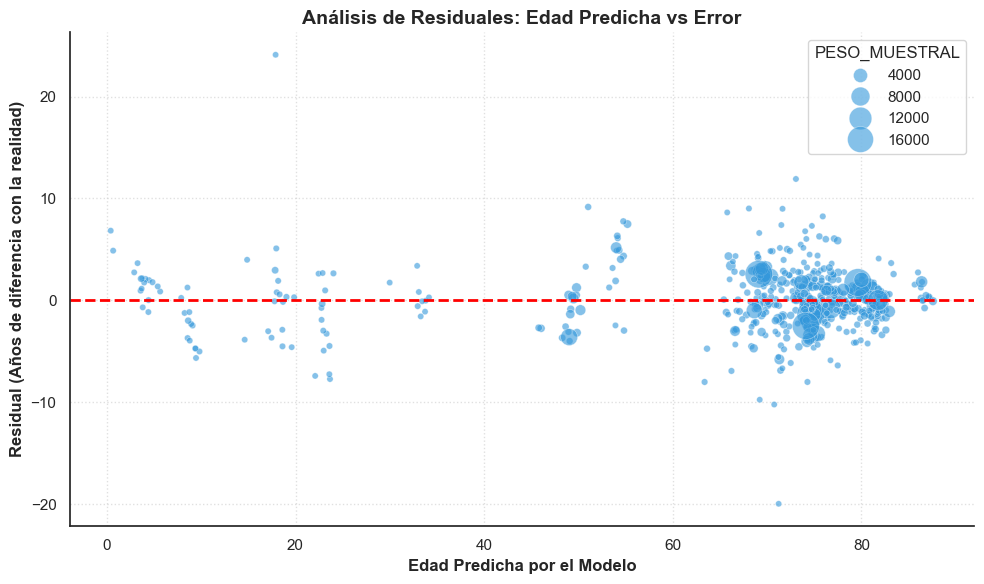

In [ ]:


# =====================================================================
# 1. SIMULADOR PREDICTIVO (Escenarios "What-If")
# =====================================================================
print("--- 1. SIMULADOR DE ESCENARIOS PREDICTIVOS ---")

# Función para predecir la edad en base a un perfil específico
def predecir_edad(sexo, region, tiene_secundaria, diagnostico):
    # Creamos un diccionario con ceros para todas las columnas que usa el modelo
    perfil = {col: 0 for col in X.columns}
    perfil['const'] = 1.0  # La constante siempre debe ser 1
    
    # Activamos (ponemos en 1) las variables según el paciente ingresado
    if f'SEXO_NOMBRE_{sexo}' in perfil:
        perfil[f'SEXO_NOMBRE_{sexo}'] = 1
    
    # Aseguramos reemplazar los espacios igual que en el modelo
    region_format = region.replace(' ', '_').replace('-', '_')
    if f'NOMBRE_REGION_{region_format}' in perfil:
        perfil[f'NOMBRE_REGION_{region_format}'] = 1
        
    if tiene_secundaria and 'TIENE_SECUNDARIA_True' in perfil:
        perfil['TIENE_SECUNDARIA_True'] = 1
        
    diag_format = diagnostico.replace(' ', '_').replace(',', '').replace('(', '').replace(')', '')
    if f'GLOSA_CAPITULO_DIAG1_{diag_format}' in perfil:
        perfil[f'GLOSA_CAPITULO_DIAG1_{diag_format}'] = 1

    # Convertimos a DataFrame para que statsmodels lo pueda leer
    df_perfil = pd.DataFrame([perfil])
    
    # Calculamos la predicción
    edad_predicha = modelo_agrupado.predict(df_perfil).values[0]
    return edad_predicha

# Probemos el simulador con dos perfiles contrastantes:
# Perfil A: Mujer en Valparaíso, sin causa secundaria, tumor
edad_A = predecir_edad(sexo='Mujer', region='De Valparaíso', tiene_secundaria=False, diagnostico='Tumores [Neoplasias]')

# Perfil B: Hombre en Tarapacá, con causa secundaria, enfermedad respiratoria
edad_B = predecir_edad(sexo='Hombre', region='De Tarapacá', tiene_secundaria=True, diagnostico='Enfermedades del sistema respiratorio ')

print(f"Predicción Perfil A (Mujer, Valparaíso, Tumor, Sin Comorbilidad): {edad_A:.1f} años")
print(f"Predicción Perfil B (Hombre, Tarapacá, Respiratorio, Con Comorbilidad): {edad_B:.1f} años")
print(f"-> Diferencia de esperanza de vida entre ambos grupos: {abs(edad_A - edad_B):.1f} años\n")


# =====================================================================
# 2. ANÁLISIS DE RESIDUALES (Descubriendo dónde falla el modelo)
# =====================================================================
print("--- 2. ANÁLISIS DE RESIDUALES (Outliers) ---") 

# Guardamos las predicciones del modelo para todos los grupos en el dataframe original
df_agrupado['PREDICCION_MODELO'] = modelo_agrupado.fittedvalues

# Calculamos el Residual: Edad Real - Edad Predicha
# Si es positivo: Vivieron más de lo esperado. Si es negativo: Murieron más jóvenes de lo esperado.
df_agrupado['RESIDUAL'] = df_agrupado['EDAD_PROMEDIO'] - df_agrupado['PREDICCION_MODELO']

# Calculamos el error absoluto para encontrar los casos donde el modelo falló por más años
df_agrupado['ERROR_ABSOLUTO'] = df_agrupado['RESIDUAL'].abs()

# Buscamos los 5 grupos demográficos donde el modelo se equivocó de forma más extrema
peores_predicciones = df_agrupado.sort_values(by='ERROR_ABSOLUTO', ascending=False).head(5)

print("Los 5 grupos demográficos con comportamiento anómalo (Outliers):")
display(peores_predicciones[['SEXO_NOMBRE', 'NOMBRE_REGION', 'TIENE_SECUNDARIA', 'GLOSA_CAPITULO_DIAG1', 'EDAD_PROMEDIO', 'PREDICCION_MODELO', 'RESIDUAL']])

# GRAFICAR LOS RESIDUALES
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PREDICCION_MODELO', y='RESIDUAL', size='PESO_MUESTRAL', sizes=(20, 400), alpha=0.6, color='#3498db', data=df_agrupado)

# Línea del cero (predicción perfecta)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Análisis de Residuales: Edad Predicha vs Error', fontsize=14, fontweight='bold')
plt.xlabel('Edad Predicha por el Modelo', fontweight='bold')
plt.ylabel('Residual (Años de diferencia con la realidad)', fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)

# Desactivar bordes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

El gráfico de residuales muestra que el modelo es altamente preciso para las cohortes con mayor peso muestral (burbujas grandes cerca del cero). Sin embargo, los valores atípicos detectados en las tablas superiores (como los casos perinatales o infecciosos) señalan áreas donde la mortalidad ocurre de forma mucho más acelerada de lo previsto por la tendencia general, marcando los puntos críticos para la intervención en salud pública.